# 04 — Publication figures, tables and reported values

**Objective.** Regenerate every figure and table of the manuscript, and every number quoted in its text, from the
data written by notebooks 01–03 (plus a few cheap deterministic simulations made here for illustration). Outputs:

* `manuscript/figures/figXX_*.pdf|png` — vector PDF for the manuscript, 400-dpi PNG for the repository;
* `manuscript/generated/tab_*.tex` — `booktabs` tables included with `\input`;
* `manuscript/generated/results_macros.tex` — `\newcommand` definitions for every number in the text;
* `results/final_results.json` — the union of all notebook summaries plus the macro values.

Run notebooks 01, 02 and 03 first (see `README.md`).

In [1]:
# --- Environment set-up (no hidden state: every notebook starts here) -------
import sys
from pathlib import Path

try:
    import pfr_uq  # installed with `pip install -e .`
except ImportError:  # fall back to the repository's src/ directory
    root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
    sys.path.insert(0, str(root / "src"))
    import pfr_uq

import numpy as np
import pandas as pd
from pfr_uq import model, solvers, metrics, uncertainty, reporting, paths

np.set_printoptions(precision=6, suppress=False)
print("pfr_uq", pfr_uq.__version__, "| numpy", np.__version__, "| repository root:", paths.ROOT.name)

pfr_uq 1.0.0 | numpy 2.5.3 | repository root: Mohamed_AIMS_Project


In [2]:
import json
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import FancyArrowPatch, Rectangle
from pfr_uq import plotting, qoi
from pfr_uq.plotting import COLORS, LINESTYLES, MARKERS, INK, MUTED, SEQ_CMAP, panel_label, save_figure
from pfr_uq.reporting import fmt_sig, fmt_sci, latex_table

plotting.set_style()
S1 = reporting.load_json("nb01_summary.json")
S2 = reporting.load_json("nb02_summary.json")
S3 = reporting.load_json("nb03_summary.json")
GEN = paths.GENERATED_TEX

def frame(records):
    """DataFrame from JSON records; tolerate NaN stored as null or as the string 'nan'."""
    return pd.DataFrame(records).replace({"nan": np.nan, "inf": np.inf, "-inf": -np.inf}).infer_objects()
MACROS = {}
P = model.BASELINE
W2 = plotting.double_column
print("loaded summaries:", list(S1)[:3], list(S2)[:3], list(S3)[:3])

loaded summaries: ['baseline', 'cn_matrix_norm_max', 'cstr_baseline_conversion'] ['A', 'B', 'C'] ['error_budget', 'exposure_fv_vs_closed_form_max_rel', 'forward']


## Figure 1 — Reactor model and finite-volume grid

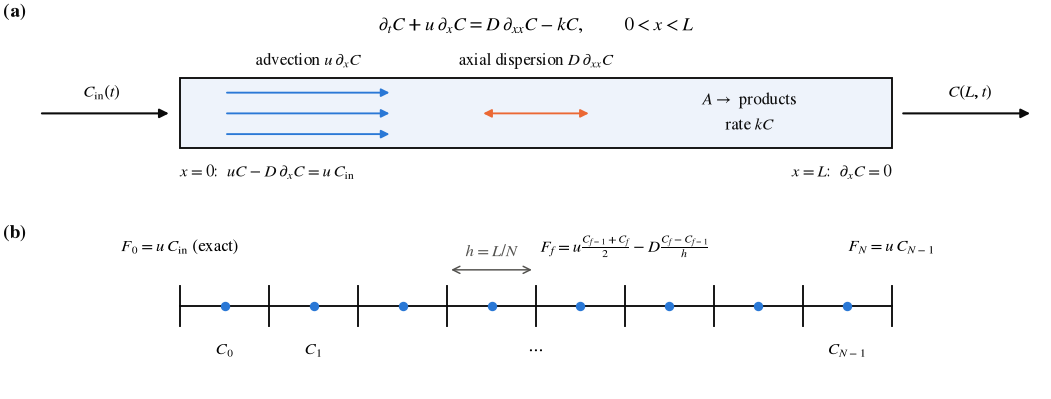

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(W2, 2.9), gridspec_kw={"height_ratios": [1.15, 1.0]})
ax = axes[0]; ax.set_xlim(-0.22, 1.22); ax.set_ylim(-0.62, 0.68); ax.axis("off")
ax.add_patch(Rectangle((0, -0.22), 1, 0.44, fc="#eef3fb", ec=INK, lw=0.9))
for y in np.linspace(-0.13, 0.13, 3):
    ax.add_patch(FancyArrowPatch((0.06, y), (0.30, y), arrowstyle="-|>", mutation_scale=8, color=COLORS[0], lw=0.9))
ax.text(0.18, 0.30, r"advection $u\,\partial_x C$", ha="center", fontsize=8, color=INK)
ax.add_patch(FancyArrowPatch((0.42, 0.0), (0.58, 0.0), arrowstyle="<|-|>", mutation_scale=8, color=COLORS[1], lw=0.9))
ax.text(0.50, 0.30, r"axial dispersion $D\,\partial_{xx}C$", ha="center", fontsize=8, color=INK)
ax.text(0.80, 0.0, r"$A\rightarrow$ products" "\n" r"rate $kC$", ha="center", va="center", fontsize=8, color=INK)
ax.add_patch(FancyArrowPatch((-0.20, 0.0), (-0.01, 0.0), arrowstyle="-|>", mutation_scale=9, color=INK, lw=1.0))
ax.add_patch(FancyArrowPatch((1.01, 0.0), (1.20, 0.0), arrowstyle="-|>", mutation_scale=9, color=INK, lw=1.0))
ax.text(-0.11, 0.10, r"$C_\mathrm{in}(t)$", ha="center", fontsize=8)
ax.text(1.11, 0.10, r"$C(L,t)$", ha="center", fontsize=8)
ax.text(0.0, -0.40, r"$x=0$:  $uC-D\,\partial_xC=u\,C_\mathrm{in}$", ha="left", fontsize=8, color=INK)
ax.text(1.0, -0.40, r"$x=L$:  $\partial_xC=0$", ha="right", fontsize=8, color=INK)
ax.text(0.5, 0.52, r"$\partial_tC+u\,\partial_xC=D\,\partial_{xx}C-kC,\qquad 0<x<L$", ha="center", fontsize=9)
panel_label(ax, "(a)", x=-0.02, y=0.92)
ax = axes[1]; ax.set_xlim(-0.22, 1.22); ax.set_ylim(-0.55, 0.55); ax.axis("off")
Nd = 8; hd = 1.0 / Nd
ax.plot([0, 1], [0, 0], color=INK, lw=0.9)
for f in range(Nd + 1):
    ax.plot([f * hd] * 2, [-0.12, 0.12], color=INK, lw=0.9)
for j in range(Nd):
    ax.plot((j + 0.5) * hd, 0, "o", color=COLORS[0], ms=3.5)
ax.text(0.5 * hd, -0.30, r"$C_0$", ha="center", fontsize=8); ax.text(1.5 * hd, -0.30, r"$C_1$", ha="center", fontsize=8)
ax.text(4 * hd, -0.30, r"$\cdots$", ha="center", fontsize=8); ax.text((Nd - 0.5) * hd, -0.30, r"$C_{N-1}$", ha="center", fontsize=8)
ax.annotate("", xy=(3 * hd, 0.22), xytext=(4 * hd, 0.22), arrowprops=dict(arrowstyle="<->", lw=0.7, color=MUTED))
ax.text(3.5 * hd, 0.30, r"$h=L/N$", ha="center", fontsize=8, color=MUTED)
ax.text(0.0, 0.33, r"$F_0=u\,C_\mathrm{in}$ (exact)", ha="center", fontsize=8)
ax.text(1.0, 0.33, r"$F_N=u\,C_{N-1}$", ha="center", fontsize=8)
ax.text(5 * hd, 0.33, r"$F_f=u\frac{C_{f-1}+C_f}{2}-D\frac{C_f-C_{f-1}}{h}$", ha="center", fontsize=8)
panel_label(ax, "(b)", x=-0.02, y=0.85)
fig.tight_layout(h_pad=0.2)
save_figure(fig, "fig01_model_schematic"); plt.show()

## Figure 2 — FTCS stability with reaction, instability demonstrations, and transport direction

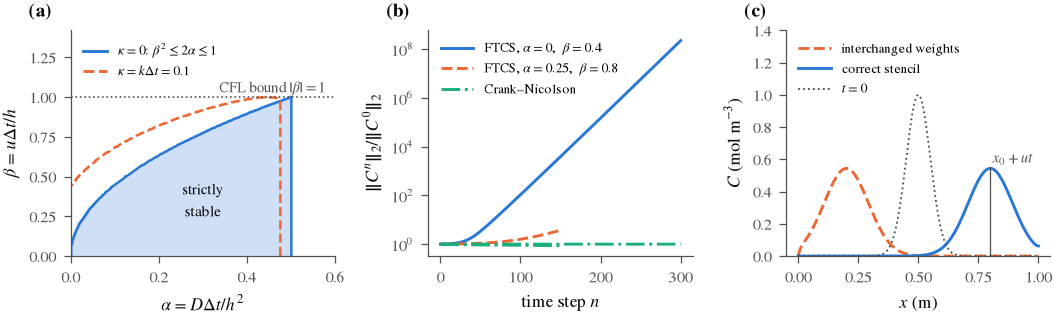

In [4]:
reg = np.load(paths.DATA / "ftcs_stability_region.npz")
gp = pd.read_csv(paths.DATA / "ftcs_growth_pure_advection.csv")
gd = pd.read_csv(paths.DATA / "ftcs_growth_adv_disp.csv")
leg = pd.read_csv(paths.DATA / "legacy_direction_profiles.csv")
fig, ax = plt.subplots(1, 3, figsize=(W2, 2.35))
A_, B_ = np.meshgrid(reg["alpha"], reg["beta"])
ax[0].contourf(A_, B_, reg["stable_k0"].astype(float), levels=[0.5, 1.5], colors=["#cfe0f6"])
ax[0].contour(A_, B_, reg["stable_k0"].astype(float), levels=[0.5], colors=[COLORS[0]], linewidths=1.2)
ax[0].contour(A_, B_, reg["stable_k01"].astype(float), levels=[0.5], colors=[COLORS[1]], linewidths=1.2, linestyles="--")
ax[0].axhline(1.0, color=MUTED, lw=0.8, ls=":")
ax[0].text(0.58, 1.03, r"CFL bound $|\beta|=1$", fontsize=7, color=MUTED, ha="right")
ax[0].text(0.30, 0.25, "strictly\nstable", fontsize=7, color=INK, ha="center")
ax[0].plot([], [], color=COLORS[0], label=r"$\kappa=0$: $\beta^2\leq2\alpha\leq1$")
ax[0].plot([], [], color=COLORS[1], ls="--", label=r"$\kappa=k\Delta t=0.1$")
ax[0].legend(loc="upper left", fontsize=6.5, handlelength=1.8)
ax[0].set(xlabel=r"$\alpha=D\Delta t/h^2$", ylabel=r"$\beta=u\Delta t/h$", xlim=(0, 0.6), ylim=(0, 1.42))
panel_label(ax[0], "(a)")
ax[1].semilogy(gp.step, gp.ftcs / gp.ftcs[0], color=COLORS[0], label=r"FTCS, $\alpha=0,\ \beta=0.4$")
ax[1].semilogy(gd.step, gd.ftcs / gd.ftcs[0], color=COLORS[1], ls="--", label=r"FTCS, $\alpha=0.25,\ \beta=0.8$")
ax[1].semilogy(gp.step, gp.cn / gp.cn[0], color=COLORS[2], ls="-.", label="Crank–Nicolson")
ax[1].semilogy(gd.step, gd.cn / gd.cn[0], color=COLORS[2], ls="-.")
ax[1].set(xlabel="time step $n$", ylabel=r"$\|C^n\|_2/\|C^0\|_2$")
ax[1].legend(fontsize=6.5, loc="upper left")
panel_label(ax[1], "(b)")
for name, col, ls in (("original", COLORS[1], "--"), ("corrected", COLORS[0], "-")):
    ax[2].plot(leg.x, leg[f"{name}_t3"], color=col, ls=ls, label={"original": "interchanged weights", "corrected": "correct stencil"}[name])
ax[2].plot(leg.x, leg["corrected_t0"], color=MUTED, lw=0.9, ls=":", label=r"$t=0$")
ax[2].axvline(0.8, ymax=0.55 / 1.4, color=MUTED, lw=0.6); ax[2].text(0.81, 0.58, r"$x_0+ut$", fontsize=7, color=MUTED)
ax[2].set(xlabel=r"$x$ (m)", ylabel=r"$C$ (mol m$^{-3}$)", ylim=(0, 1.4))
ax[2].legend(fontsize=6.5, loc="upper left")
panel_label(ax[2], "(c)")
fig.tight_layout(w_pad=1.0)
save_figure(fig, "fig02_ftcs_stability"); plt.show()

## Figure 3 — Verification benchmarks

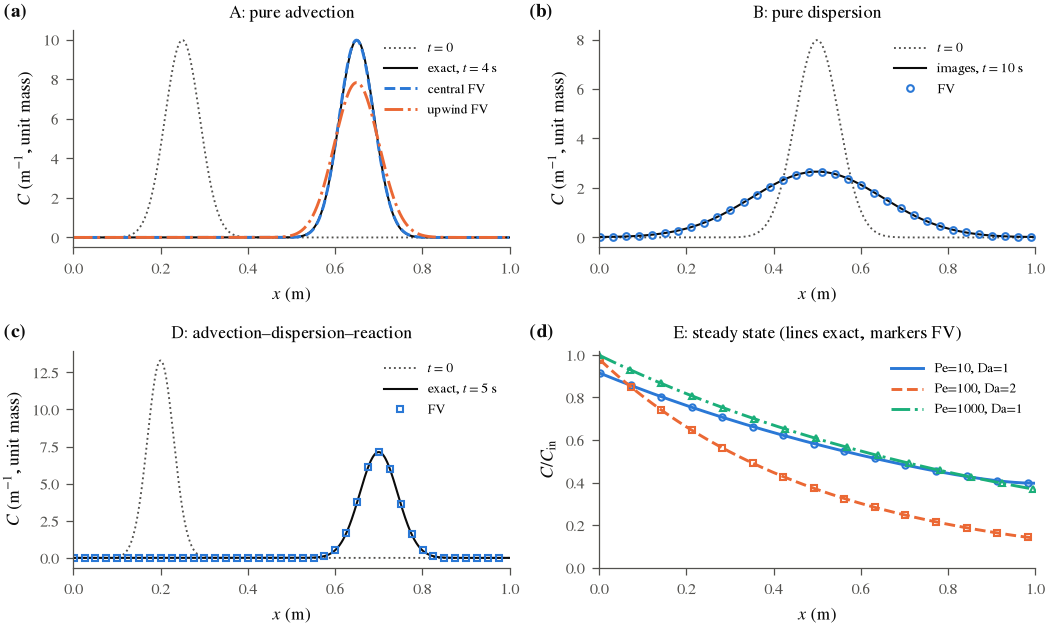

In [5]:
bA = pd.read_csv(paths.DATA / "benchA_profiles.csv"); bB = pd.read_csv(paths.DATA / "benchB_profiles.csv")
bD = pd.read_csv(paths.DATA / "benchD_profiles.csv"); bE = pd.read_csv(paths.DATA / "benchE_profiles.csv")
fig, ax = plt.subplots(2, 2, figsize=(W2, 4.4))
a = ax[0, 0]
a.plot(bA.x, bA.initial, color=MUTED, lw=0.9, ls=":", label=r"$t=0$")
a.plot(bA.x, bA.exact, color=INK, lw=1.0, label="exact, $t=4$ s")
a.plot(bA.x, bA.central, color=COLORS[0], ls="--", label="central FV")
a.plot(bA.x, bA.upwind, color=COLORS[1], ls="-.", label="upwind FV")
a.set(xlabel=r"$x$ (m)", ylabel=r"$C$ (mol m$^{-2}$ per unit mass)", xlim=(0, 1), title="A: pure advection")
a.set_ylabel(r"$C$ (m$^{-1}$, unit mass)")
a.legend(fontsize=6.5); panel_label(a, "(a)")
a = ax[0, 1]
a.plot(bB.x, bB.initial, color=MUTED, lw=0.9, ls=":", label=r"$t=0$")
a.plot(bB.x, bB.exact, color=INK, lw=1.0, label="images, $t=10$ s")
a.plot(bB.x[::12], bB.numerical[::12], "o", color=COLORS[0], ms=3.2, mfc="none", label="FV")
a.set(xlabel=r"$x$ (m)", ylabel=r"$C$ (m$^{-1}$, unit mass)", xlim=(0, 1), title="B: pure dispersion")
a.legend(fontsize=6.5); panel_label(a, "(b)")
a = ax[1, 0]
a.plot(bD.x, bD.initial, color=MUTED, lw=0.9, ls=":", label=r"$t=0$")
a.plot(bD.x, bD.exact, color=INK, lw=1.0, label="exact, $t=5$ s")
a.plot(bD.x[::20], bD.numerical[::20], "s", color=COLORS[0], ms=3.0, mfc="none", label="FV")
a.set(xlabel=r"$x$ (m)", ylabel=r"$C$ (m$^{-1}$, unit mass)", xlim=(0, 1), title="D: advection–dispersion–reaction")
a.legend(fontsize=6.5); panel_label(a, "(c)")
a = ax[1, 1]
for i, (case, d) in enumerate(bE.groupby("case", sort=False)):
    a.plot(d.x, d.exact, color=COLORS[i], ls=LINESTYLES[i], label=case.replace("Pe", r"$\mathrm{Pe}$").replace("Da", r"$\mathrm{Da}$"))
    step = max(1, len(d) // 14)
    a.plot(d.x.values[::step], d.numerical.values[::step], MARKERS[i], color=COLORS[i], ms=3.0, mfc="none")
a.set(xlabel=r"$x$ (m)", ylabel=r"$C/C_\mathrm{in}$", xlim=(0, 1), ylim=(0, 1.02), title="E: steady state (lines exact, markers FV)")
a.legend(fontsize=6.5); panel_label(a, "(d)")
fig.tight_layout()
save_figure(fig, "fig03_verification"); plt.show()

## Figure 4 — Measured spatial and temporal convergence

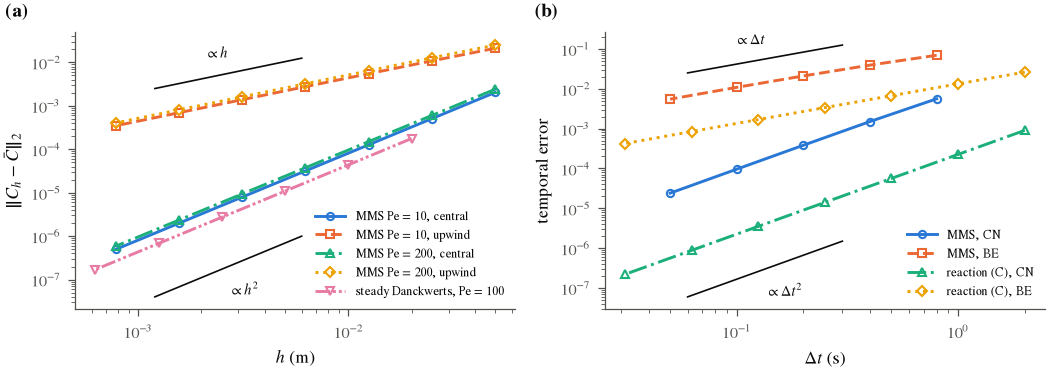

In [6]:
ms = pd.read_csv(paths.TABLES / "convergence_space_mms.csv")
mt = pd.read_csv(paths.TABLES / "convergence_time_mms.csv")
cC = pd.read_csv(paths.TABLES / "convergence_benchC.csv")
cE = pd.read_csv(paths.TABLES / "convergence_benchE.csv")
cA = pd.read_csv(paths.TABLES / "convergence_benchA.csv")
fig, ax = plt.subplots(1, 2, figsize=(W2, 2.7))
a = ax[0]; i = 0
for (case, adv), d in ms.groupby(["case", "advection"], sort=False):
    a.loglog(d.h, d.L2, marker=MARKERS[i], color=COLORS[i], ls=LINESTYLES[i], ms=3.5, mfc="none",
             label=f"MMS {case.split(',')[0].replace('Pe', 'Pe ').replace('=', '= ')}, {adv}")
    i += 1
d = cE[cE.case == "Pe=100, Da=2"]
a.loglog(d.h, d.L2, marker=MARKERS[4], color=COLORS[4], ls=LINESTYLES[4], ms=3.5, mfc="none", label="steady Danckwerts, Pe = 100")
def ref_segment(a, x0, x1, y0, slope, label, above=False):
    xs = np.array([x0, x1]); a.loglog(xs, y0 * (xs / x0) ** slope, color=INK, lw=0.8)
    ym = y0 * (np.sqrt(x1 / x0)) ** slope
    a.text(np.sqrt(x0 * x1), ym * (1.9 if above else 0.45), label, fontsize=7, color=INK, ha="right" if above else "left",
           va="bottom" if above else "top")
ref_segment(a, 1.2e-3, 6e-3, 4e-8, 2, r"$\propto h^2$")
ref_segment(a, 1.2e-3, 6e-3, 2.5e-3, 1, r"$\propto h$", above=True)
a.set(xlabel=r"$h$ (m)", ylabel=r"$\|C_h-\bar C\|_2$")
a.legend(fontsize=6, loc="lower right"); panel_label(a, "(a)")
a = ax[1]
for i, (sch, d) in enumerate(mt[mt.scheme.isin(["CN", "BE"])].groupby("scheme", sort=False)):
    a.loglog(d.dt, d["L2 temporal"], marker=MARKERS[i], color=COLORS[i], ls=LINESTYLES[i], ms=3.5, mfc="none", label=f"MMS, {sch}")
for i, (sch, d) in enumerate(cC[cC.scheme.isin(["CN", "BE"])].groupby("scheme", sort=False)):
    a.loglog(d.dt, d.err, marker=MARKERS[i + 2], color=COLORS[i + 2], ls=LINESTYLES[i + 2], ms=3.5, mfc="none", label=f"reaction (C), {sch}")
ref_segment(a, 0.06, 0.3, 6e-8, 2, r"$\propto\Delta t^2$")
ref_segment(a, 0.06, 0.3, 2.5e-2, 1, r"$\propto\Delta t$", above=True)
a.set(xlabel=r"$\Delta t$ (s)", ylabel="temporal error")
a.legend(fontsize=6, loc="lower right"); panel_label(a, "(b)")
fig.tight_layout()
save_figure(fig, "fig04_convergence"); plt.show()

## Figure 5 — Deterministic transport and reaction regimes

Cheap deterministic simulations with the production solver ($N=400$ or $N\ge2\mathrm{Pe}$ so that the cell Péclet
number is at most 1, $\Delta t=0.025$ s): exit response to the Gaussian feed pulse and steady profiles at $\mathrm{Da}=1$ for
several $\mathrm{Pe}$, plus the steady conversion map with its PFR and CSTR limits.

min concentration in regime runs: -1.0010623373077371e-66


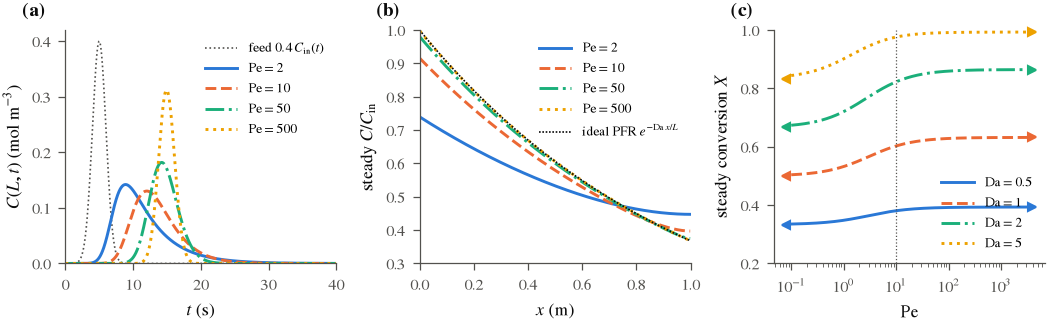

conversion at Pe=10: {1.0: 0.6027332266938733, 5.0: 0.976121065436405} PFR: {1.0: 0.6321205588285577, 5.0: 0.9932620530009145} peak by Pe: {2.0: 0.14207141089810613, 10.0: 0.1303406382791697, 50.0: 0.18182893897041863, 500.0: 0.31228300478898136}


In [7]:
PE_SET = [2.0, 10.0, 50.0, 500.0]
curves, profiles = {}, {}
for Pe in PE_SET:
    D_ = P.u * P.L / Pe
    N = int(max(400, 2 * Pe))
    op = solvers.FVOperator(P.u, D_, P.k, P.L, N)
    res = solvers.integrate(op, 0.0, 40.0, 0.025, inlet=lambda t: model.gaussian_inlet_pulse(t, 1.0, 5.0, 1.0))
    curves[Pe] = (res.t, res.outlet[:, 0], res.inlet[:, 0], res.min_value)
    profiles[Pe] = (op.grid.centers, solvers.solve_steady(op, 1.0)[0])
print("min concentration in regime runs:", min(v[3] for v in curves.values()))
pe_line = np.logspace(-1, 3.5, 300)
fig, ax = plt.subplots(1, 3, figsize=(W2, 2.4))
a = ax[0]
a.plot(curves[2.0][0], 0.4 * curves[2.0][2], color=MUTED, lw=0.8, ls=":", label=r"feed $0.4\,C_\mathrm{in}(t)$")
for i, Pe in enumerate(PE_SET):
    a.plot(curves[Pe][0], curves[Pe][1], color=COLORS[i], ls=LINESTYLES[i], label=rf"$\mathrm{{Pe}}={Pe:g}$")
a.set(xlabel=r"$t$ (s)", ylabel=r"$C(L,t)$ (mol m$^{-3}$)", xlim=(0, 40), ylim=(0, 0.42))
a.legend(fontsize=6.5); panel_label(a, "(a)")
a = ax[1]
for i, Pe in enumerate(PE_SET):
    a.plot(profiles[Pe][0], profiles[Pe][1], color=COLORS[i], ls=LINESTYLES[i], label=rf"$\mathrm{{Pe}}={Pe:g}$")
xx = np.linspace(0, 1, 200)
a.plot(xx, np.exp(-P.Da * xx), color=INK, lw=0.8, ls=(0, (1, 1)), label=r"ideal PFR $e^{-\mathrm{Da}\,x/L}$")
a.set(xlabel=r"$x$ (m)", ylabel=r"steady $C/C_\mathrm{in}$", xlim=(0, 1), ylim=(0.3, 1.0))
a.legend(fontsize=6.5); panel_label(a, "(b)")
a = ax[2]
for i, Da in enumerate([0.5, 1.0, 2.0, 5.0]):
    X = 1 - model.danckwerts_outlet_ratio(pe_line, Da)
    a.semilogx(pe_line, X, color=COLORS[i], ls=LINESTYLES[i], label=rf"$\mathrm{{Da}}={Da:g}$")
    a.plot(pe_line[-1] * 1.25, 1 - np.exp(-Da), ">", color=COLORS[i], ms=3.5, clip_on=False)
    a.plot(pe_line[0] / 1.25, Da / (1 + Da), "<", color=COLORS[i], ms=3.5, clip_on=False)
a.axvline(P.Pe, color=MUTED, lw=0.6, ls=":")
a.set(xlabel=r"$\mathrm{Pe}$", ylabel=r"steady conversion $X$", ylim=(0.2, 1.0))
a.legend(fontsize=6.5, loc="lower right"); panel_label(a, "(c)")
fig.tight_layout(w_pad=0.8)
save_figure(fig, "fig05_transport_regimes"); plt.show()
X_pe10 = {Da: float(1 - model.danckwerts_outlet_ratio(10.0, Da)) for Da in (1.0, 5.0)}
X_pfr = {Da: float(1 - np.exp(-Da)) for Da in (1.0, 5.0)}
peak_by_pe = {Pe: float(curves[Pe][1].max()) for Pe in PE_SET}
print("conversion at Pe=10:", X_pe10, "PFR:", X_pfr, "peak by Pe:", peak_by_pe)

## Figure 6 — Forward propagation and variance-based sensitivity at the baseline

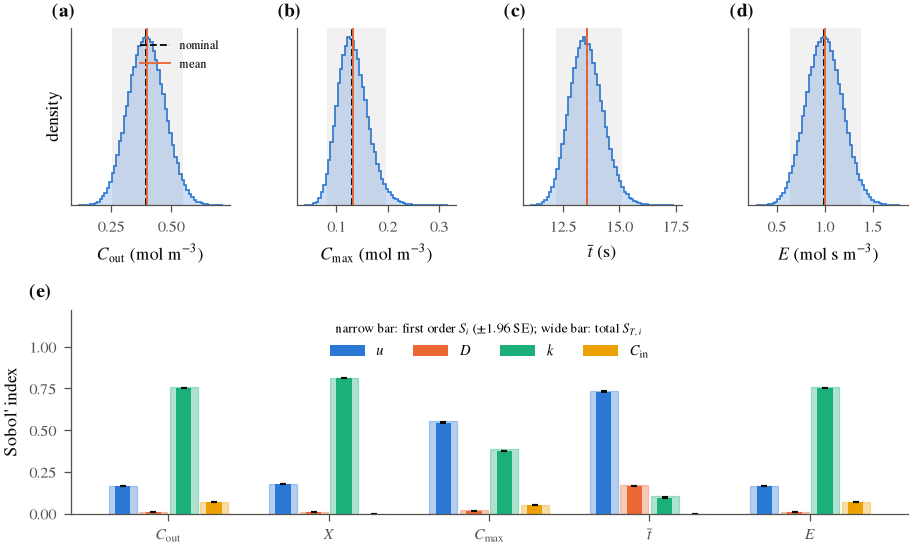

In [8]:
H = np.load(paths.DATA / "forward_uq_histograms.npz")
fw = pd.read_csv(paths.TABLES / "forward_uq_baseline.csv").set_index("QoI")
sb = pd.read_csv(paths.TABLES / "sobol_baseline.csv")
QSHOW = ["C_out", "peak", "t_mean", "exposure"]
XL = {"C_out": r"$C_\mathrm{out}$ (mol m$^{-3}$)", "peak": r"$C_\mathrm{max}$ (mol m$^{-3}$)", "t_mean": r"$\bar t$ (s)",
      "exposure": r"$E$ (mol s m$^{-3}$)", "X": r"$X$ (–)"}
fig = plt.figure(figsize=(W2, 4.2))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.15], hspace=0.55, wspace=0.42)
for i, q in enumerate(QSHOW):
    a = fig.add_subplot(gs[0, i])
    e = H[f"{q}_edges"]; dns = H[f"{q}_density"]
    a.stairs(dns, e, fill=True, color="#cfe0f6"); a.stairs(dns, e, color=COLORS[0], lw=0.8)
    a.axvline(fw.loc[q, "nominal"], color=INK, lw=0.9, ls="--", label="nominal")
    a.axvline(fw.loc[q, "mean"], color=COLORS[1], lw=0.9, label="mean")
    a.axvspan(fw.loc[q, "2.5%"], fw.loc[q, "97.5%"], color=MUTED, alpha=0.08, lw=0)
    a.set(xlabel=XL[q], yticks=[])
    if i == 0:
        a.set_ylabel("density"); a.legend(fontsize=6, loc="upper right")
    panel_label(a, f"({'abcd'[i]})", x=-0.12)
a = fig.add_subplot(gs[1, :])
qs = ["C_out", "X", "peak", "t_mean", "exposure"]; ins = ["u", "D", "k", "C_in"]
w = 0.19
for i, inp in enumerate(ins):
    d = sb[sb.input == inp].set_index("QoI").loc[qs]
    xpos = np.arange(len(qs)) + (i - 1.5) * w
    a.bar(xpos, d.ST, width=w * 0.92, color=COLORS[i], alpha=0.35, edgecolor=COLORS[i], lw=0.6)
    a.bar(xpos, d.S.clip(lower=0), width=w * 0.5, color=COLORS[i], label={"u": "$u$", "D": "$D$", "k": "$k$", "C_in": r"$C_\mathrm{in}$"}[inp])
    a.errorbar(xpos, d.S, yerr=1.96 * d["S SE"], fmt="none", ecolor=INK, elinewidth=0.6, capsize=1.5)
a.set_xticks(np.arange(len(qs)), [XL[q].split(" (")[0] for q in qs])
a.set(ylabel="Sobol' index", ylim=(0, 1.22))
a.legend(ncol=4, fontsize=7, loc="upper center", title="narrow bar: first order $S_i$ (±1.96 SE); wide bar: total $S_{T,i}$", title_fontsize=6.5)
panel_label(a, "(e)", x=-0.05)
save_figure(fig, "fig06_parametric_uq"); plt.show()

## Figure 7 — Uncertainty across the Pe–Da plane

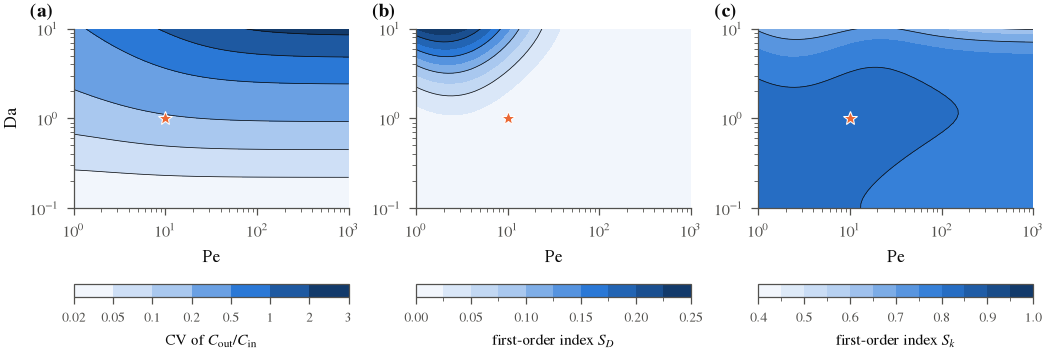

In [9]:
RM = np.load(paths.DATA / "regime_maps.npz")
fig, ax = plt.subplots(1, 3, figsize=(W2, 2.55))
PEg, DAg = np.meshgrid(RM["Pe"], RM["Da"])
specs = [("cv_G", r"CV of $C_\mathrm{out}/C_\mathrm{in}$", np.array([0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 3.0]), "log"),
         ("S_D", r"first-order index $S_D$", np.linspace(0, 0.25, 11), "lin"),
         ("S_k", r"first-order index $S_k$", np.linspace(0.4, 1.0, 13), "lin")]
for i, (key, lab, lev, scale) in enumerate(specs):
    a = ax[i]
    Z = np.clip(RM[key], lev[0], lev[-1])
    norm = mpl.colors.BoundaryNorm(lev, SEQ_CMAP.N)
    cf = a.contourf(PEg, DAg, Z, levels=lev, cmap=SEQ_CMAP, norm=norm)
    a.contour(PEg, DAg, Z, levels=(lev[1:-1] if scale == "log" else lev[2:-1:2]), colors=[INK], linewidths=0.35)
    a.set_xscale("log"); a.set_yscale("log")
    a.plot(P.Pe, P.Da, "*", color=COLORS[1], ms=7, mec="white", mew=0.5)
    a.set(xlabel=r"$\mathrm{Pe}$", ylabel=r"$\mathrm{Da}$" if i == 0 else "")
    cb = fig.colorbar(cf, ax=a, orientation="horizontal", pad=0.28, fraction=0.06, aspect=22, spacing="uniform")
    cb.set_label(lab, fontsize=7.5); cb.ax.tick_params(labelsize=6.5)
    cb.set_ticks(lev if scale == "log" else lev[::2])
    if scale == "log":
        cb.set_ticklabels([f"{v:g}" for v in lev])
    panel_label(a, f"({'abc'[i]})")
fig.tight_layout(w_pad=0.6)
save_figure(fig, "fig07_regime_uq"); plt.show()

## Figure 8 — Monte Carlo versus randomized quasi-Monte Carlo

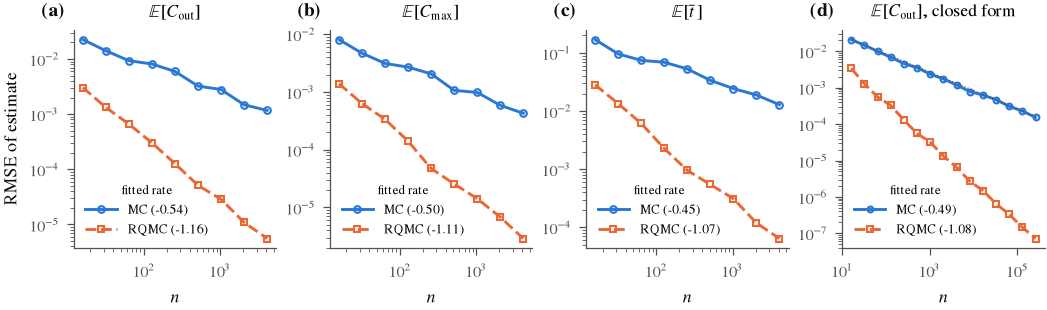

In [10]:
cur = pd.read_csv(paths.DATA / "mcqmc_rmse_curves.csv")
ext = pd.read_csv(paths.DATA / "mcqmc_steady_extended.csv")
rates = pd.read_csv(paths.TABLES / "mcqmc_rates.csv")
fig, ax = plt.subplots(1, 4, figsize=(W2, 2.3))
panels = [("C_out", "mean", r"$\mathbb{E}[C_\mathrm{out}]$"), ("peak", "mean", r"$\mathbb{E}[C_\mathrm{max}]$"),
          ("t_mean", "mean", r"$\mathbb{E}[\bar t\,]$")]
for i, (q, st, title) in enumerate(panels):
    a = ax[i]
    for j, (m, lab) in enumerate((("mc", "MC"), ("rqmc", "RQMC"))):
        d = cur[(cur.QoI == q) & (cur.estimator == st) & (cur.method == m)]
        r = rates[(rates.QoI == q) & (rates.estimator == st) & (rates.method == m)].iloc[0]
        a.loglog(d.n, d.rmse, marker=MARKERS[j], color=COLORS[j], ls=LINESTYLES[j], ms=3.2, mfc="none",
                 label=f"{lab} ({r['rate']:.2f})")
    n0 = d.n.values
    a.set(xlabel="$n$", title=title)
    if i == 0:
        a.set_ylabel("RMSE of estimate")
    a.legend(fontsize=6.3, loc="lower left", title="fitted rate", title_fontsize=6)
    panel_label(a, f"({'abcd'[i]})")
a = ax[3]
for j, (col, lab) in enumerate((("rmse_mc", "MC"), ("rmse_rqmc", "RQMC"))):
    a.loglog(ext.n, ext[col], marker=MARKERS[j], color=COLORS[j], ls=LINESTYLES[j], ms=2.8, mfc="none",
             label=f"{lab} ({S3['mcqmc_steady_extended']['rate_' + col.split('_')[1]]:.2f})")
nn = np.array([2.0**4, 2.0**18])
a.loglog(nn, ext.rmse_mc.iloc[0] * (nn / nn[0]) ** -0.5, color=MUTED, lw=0.6, ls=":")
a.set(xlabel="$n$", title=r"$\mathbb{E}[C_\mathrm{out}]$, closed form")
a.legend(fontsize=6.3, loc="lower left", title="fitted rate", title_fontsize=6)
panel_label(a, "(d)")
fig.tight_layout(w_pad=0.5)
save_figure(fig, "fig08_mc_qmc"); plt.show()

## Figure 9 — Measurement error: random noise versus systematic offset

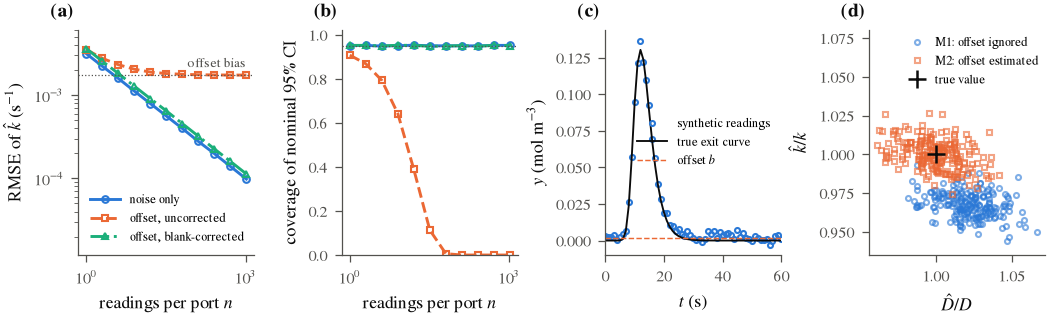

In [11]:
inf = pd.read_csv(paths.TABLES / "steady_inference.csv")
fits = pd.read_csv(paths.DATA / "transient_fits.csv")
tf = np.load(paths.DATA / "transient_fit_data.npz")
si = S3["steady_inference"]
fig, ax = plt.subplots(1, 4, figsize=(W2, 2.35))
lab = {"S1 noise only": "noise only", "S2 offset, uncorrected": "offset, uncorrected", "S3 offset, blank-corrected": "offset, blank-corrected"}
a = ax[0]
for i, (case, d) in enumerate(inf.groupby("case", sort=False)):
    a.loglog(d.n, d.rmse, marker=MARKERS[i], color=COLORS[i], ls=LINESTYLES[i], ms=3.2, mfc="none", label=lab[case])
a.axhline(abs(si["asymptotic_bias"]), color=MUTED, lw=0.6, ls=":")
a.text(1000, abs(si["asymptotic_bias"]) * 1.25, "offset bias", fontsize=6.5, color=MUTED, ha="right")
a.set(xlabel="readings per port $n$", ylabel=r"RMSE of $\hat k$ (s$^{-1}$)", ylim=(1.2e-5, 6e-3))
a.legend(fontsize=6, loc="lower left"); panel_label(a, "(a)")
a = ax[1]
for i, (case, d) in enumerate(inf.groupby("case", sort=False)):
    a.semilogx(d.n, d["coverage 95% CI"], marker=MARKERS[i], color=COLORS[i], ls=LINESTYLES[i], ms=3.2, mfc="none")
a.axhline(0.95, color=MUTED, lw=0.6, ls=":")
a.set(xlabel="readings per port $n$", ylabel="coverage of nominal 95% CI", ylim=(0, 1.02)); panel_label(a, "(b)")
a = ax[2]
a.plot(tf["t_obs"], tf["example_y"], "o", ms=2.4, color=COLORS[0], mfc="none", label="synthetic readings")
a.plot(tf["t_obs"], tf["y_true"], color=INK, lw=0.9, label="true exit curve")
a.axhline(S3["transient_fit"]["b"], color=COLORS[1], lw=0.7, ls="--", label="offset $b$")
a.set(xlabel=r"$t$ (s)", ylabel=r"$y$ (mol m$^{-3}$)", xlim=(0, 60)); a.legend(fontsize=6, loc="center right"); panel_label(a, "(c)")
a = ax[3]
for i, (m, d) in enumerate(fits.groupby("model", sort=False)):
    a.plot(np.exp(d.lnD) / P.D, np.exp(d.lnk) / P.k, MARKERS[i], color=COLORS[i], ms=2.4, alpha=0.6, mfc="none",
           label={"M1 no offset": "M1: offset ignored", "M2 offset estimated": "M2: offset estimated"}[m])
a.plot(1, 1, "+", color=INK, ms=9, mew=1.2, label="true value")
a.set(xlabel=r"$\hat D/D$", ylabel=r"$\hat k/k$", ylim=(0.935, 1.08)); a.legend(fontsize=6, loc="upper right", handletextpad=0.2, borderaxespad=0.1); panel_label(a, "(d)")
fig.tight_layout(w_pad=0.4)
save_figure(fig, "fig09_measurement_error"); plt.show()

## Tables (LaTeX, `booktabs`)

In [12]:
def s(x, n=3):
    return fmt_sig(float(x), n)
def e(x, n=2):
    return fmt_sci(float(x), n)

# Table 1: parameters
par = pd.read_csv(paths.TABLES / "parameters.csv")
sym = {"L": "$L$", "u": "$u$", "D": "$D$", "k": "$k$", "C_in": r"$C_\mathrm{in}$", "tau_a": r"$\tau_a=L/u$", "tau_d": r"$\tau_d=L^2/D$",
       "tau_r": r"$\tau_r=1/k$", "Pe": r"$\mathrm{Pe}=uL/D$", "Da": r"$\mathrm{Da}=kL/u$"}
unit = {"m": "m", "m s^-1": r"m\,s$^{-1}$", "m^2 s^-1": r"m$^2$\,s$^{-1}$", "s^-1": r"s$^{-1}$", "mol m^-3": r"mol\,m$^{-3}$", "s": "s", "-": "--"}
desc = {"L": "reactor length", "u": "mean axial velocity", "D": "axial dispersion coefficient", "k": "first-order rate constant",
        "C_in": "feed concentration", "tau_a": "space (advective) time", "tau_d": "dispersion time", "tau_r": "reaction time",
        "Pe": "axial P\\'eclet number", "Da": "Damk\\\"ohler number"}
rows = [[sym[r["symbol"]], desc[r["symbol"]], s(r["value"], 3), unit[r["unit"]]] for r in par.to_dict("records")]
latex_table(rows, ["Symbol", "Definition", "Baseline", "Unit"], GEN / "tab_parameters.tex", "llrl")

inp = pd.read_csv(paths.TABLES / "input_distributions.csv")
isym = {"u": "$u$", "D": "$D$", "k": "$k$", "C_in": r"$C_\mathrm{in}$"}
rows = [[isym[r["input"]], unit[r["unit"]], s(r["median"]), f"{r['CV']:.2f}", s(r["2.5%"]), s(r["97.5%"])] for r in inp.to_dict("records")]
latex_table(rows, ["Input", "Unit", "Median", "CV", "2.5\\% quantile", "97.5\\% quantile"], GEN / "tab_inputs.tex", "llrrrr")

# Table: verification summary
A = frame(S2["A"]["convergence"]); B = frame(S2["B"]["convergence"]); D = frame(S2["D"]["convergence"])
E = frame(S2["E"]["convergence"]); F = frame(S2["F"]); C = frame(S2["C"])
def last(df, col):
    return df.iloc[-1][col]
rows = [
    ["A", "pure advection, central", "translated Gaussian", e(last(A[A.case == 'A-central'], 'L2')), f"{last(A[A.case == 'A-central'], 'p_L2'):.2f}"],
    ["A", "pure advection, upwind", "translated Gaussian", e(last(A[A.case == 'A-upwind'], 'L2')), f"{last(A[A.case == 'A-upwind'], 'p_L2'):.2f}"],
    ["B", "pure dispersion (closed)", "method of images", e(last(B, 'L2')), f"{last(B, 'p_L2'):.2f}"],
    ["C", "reaction, Crank--Nicolson", "$e^{-kt}$", e(last(C[C.scheme == 'CN'], 'err')), f"{last(C[C.scheme == 'CN'], 'p_err'):.2f}"],
    ["D", "advection--dispersion--reaction", "infinite-domain Gaussian", e(last(D, 'L2')), f"{last(D, 'p_L2'):.2f}"],
]
for case in ["Pe=10, Da=1", "Pe=100, Da=2", "Pe=1000, Da=1"]:
    d = E[E.case == case]
    rows.append(["E", "steady, " + case.replace("Pe", "$\\mathrm{Pe}$").replace("Da", "$\\mathrm{Da}$"), "Wehner--Wilhelm profile", e(last(d, 'L2')), f"{last(d, 'p_L2'):.2f}"])
latex_table(rows, ["", "Case", "Reference", "$L^2$ error (finest)", "Observed order"], GEN / "tab_verification.tex", "lllrr")

rows = []
for r in F.to_dict("records"):
    rows.append([f"{r['Pe']:g}", f"{r['Da']:g}", f"{r['yield num']:.6f}", f"{r['yield exact']:.6f}", f"{r['mean shift num [s]']:.4f}",
                 f"{r['mean shift exact [s]']:.4f}", f"{r['var shift num [s^2]']:.3f}", f"{r['var shift exact [s^2]']:.3f}"])
latex_table(rows, [r"$\mathrm{Pe}$", r"$\mathrm{Da}$", "yield (FV)", "yield (exact)", r"$\Delta\bar t$ FV (s)", r"$\Delta\bar t$ exact (s)",
                   r"$\Delta\sigma^2$ FV (s$^2$)", r"$\Delta\sigma^2$ exact (s$^2$)"], GEN / "tab_moments.tex", "rrrrrrrr")

# Table: MMS convergence
ms = pd.read_csv(paths.TABLES / "convergence_space_mms.csv")
mt = pd.read_csv(paths.TABLES / "convergence_time_mms.csv")
rows = []
for N in (20, 80, 320, 1280):
    r = [str(N), s(1.0 / N, 3)]
    for case, adv in (("Pe=10, Da=1", "central"), ("Pe=200, Da=1", "central"), ("Pe=10, Da=1", "upwind")):
        d = ms[(ms.case == case) & (ms.advection == adv) & (ms.N == N)].iloc[0]
        r += [e(d.L2), "--" if np.isnan(d.p_L2) else f"{d.p_L2:.2f}"]
    rows.append(r)
latex_table(rows, ["$N$", "$h$ (m)", "$L^2$, Pe$=$10, central", "$p$", "$L^2$, Pe$=$200, central", "$p$", "$L^2$, Pe$=$10, upwind", "$p$"],
            GEN / "tab_convergence_space.tex", "rrrrrrrr")
rows = []
for n in (5, 10, 20, 40, 80):
    r = [str(n), s(4.0 / n, 2)]
    for sch in ("CN", "BE"):
        d = mt[(mt.scheme == sch) & (mt.n_steps == n)].iloc[0]
        r += [e(d["L2 temporal"]), "--" if np.isnan(d["p_L2 temporal"]) else f"{d['p_L2 temporal']:.2f}"]
    rows.append(r)
latex_table(rows, ["steps", r"$\Delta t$ (s)", "CN error", "$p$", "BE error", "$p$"], GEN / "tab_convergence_time.tex", "rrrrrr")

# Table: production accuracy & error budget
bud = pd.read_csv(paths.TABLES / "error_budget.csv")
qlab = {"C_out": r"$C_\mathrm{out}$", "X": "$X$", "peak": r"$C_\mathrm{max}$", "t_mean": r"$\bar t$", "exposure": "$E$"}
qunit = {"C_out": r"mol\,m$^{-3}$", "X": "--", "peak": r"mol\,m$^{-3}$", "t_mean": "s", "exposure": r"mol\,s\,m$^{-3}$"}
rows = [[qlab[r["QoI"]], qunit[r["QoI"]], s(r["parametric sd"], 3), e(r["discretisation error"]), e(r["MC SE (n=4096)"]), e(r["RQMC SE (n=4096)"])] for r in bud.to_dict("records")]
latex_table(rows, ["QoI", "Unit", "Parametric s.d.", "Discretisation error", "MC s.e. ($n=4096$)", "RQMC s.e. ($n=4096$)"], GEN / "tab_error_budget.tex", "llrrrr")

# Table: forward UQ
fw = pd.read_csv(paths.TABLES / "forward_uq_baseline.csv")
rows = [[qlab[r["QoI"]], qunit[r["QoI"]], s(r["nominal"], 4), s(r["mean"], 4), e(r["mean SE"]), s(r["sd"], 3), f"{r['CV']:.3f}",
         f"[{s(r['2.5%'], 3)}, {s(r['97.5%'], 3)}]"] for r in fw.to_dict("records")]
latex_table(rows, ["QoI", "Unit", "Nominal", "Mean", "s.e. of mean", "s.d.", "CV", "95\\% interval"], GEN / "tab_forward_uq.tex", "llrrrrrc")

# Table: MC vs RQMC
rt = pd.read_csv(paths.TABLES / "mcqmc_rates.csv"); vr = pd.read_csv(paths.TABLES / "mcqmc_efficiency.csv")
rows = []
for q in ["C_out", "X", "peak", "t_mean", "exposure"]:
    r = [qlab[q]]
    for m in ("mc", "rqmc"):
        d = rt[(rt.QoI == q) & (rt.estimator == "mean") & (rt.method == m)].iloc[0]
        r.append(f"${d.rate:.2f}$ [${d['rate 95% CI low']:.2f}$, ${d['rate 95% CI high']:.2f}$]")
    v = vr[(vr.QoI == q) & (vr.estimator == "mean")].iloc[0]
    r.append(f"{e(v['MSE ratio MC/RQMC'])} [{e(v['95% CI low'])}, {e(v['95% CI high'])}]")
    d = rt[(rt.QoI == q) & (rt.estimator == "var") & (rt.method == "rqmc")].iloc[0]
    v2 = vr[(vr.QoI == q) & (vr.estimator == "var")].iloc[0]
    r += [f"${d.rate:.2f}$", e(v2['MSE ratio MC/RQMC'])]
    rows.append(r)
latex_table(rows, ["QoI", "MC rate", "RQMC rate", "MSE ratio (mean)", "RQMC rate (var.)", "MSE ratio (var.)"], GEN / "tab_mcqmc.tex", "lccccc")

# Table: measurement experiments
inf = pd.read_csv(paths.TABLES / "steady_inference.csv")
rows = []
for n in (1, 16, 256, 1024):
    for case in ["S1 noise only", "S2 offset, uncorrected", "S3 offset, blank-corrected"]:
        d = inf[(inf.case == case) & (inf.n == n)].iloc[0]
        rows.append([str(n) if case.startswith("S1") else "", case.split(" ", 1)[1], e(d.bias), e(d.sd), e(d.rmse),
                     f"{d['coverage 95% CI']:.3f}"])
    if n != 1024:
        rows.append("midrule")
latex_table(rows, ["$n$", "Case", r"Bias of $\hat k$ (s$^{-1}$)", r"s.d. (s$^{-1}$)", r"RMSE (s$^{-1}$)", "Coverage"], GEN / "tab_steady_inference.tex", "rlrrrr")
tfs = pd.read_csv(paths.TABLES / "transient_fit_summary.csv")
rows = []
for r in tfs.to_dict("records"):
    rows.append([r["model"].split(" ", 1)[1], f"${100 * r['D rel bias']:+.2f}$", f"{100 * r['D rel sd']:.2f}", f"${100 * r['k rel bias']:+.2f}$",
                 f"{100 * r['k rel sd']:.2f}", f"{r['coverage D']:.2f} {r['coverage D CI']}", f"{r['coverage k']:.2f} {r['coverage k CI']}"])
latex_table(rows, ["Estimator", r"$D$ bias (\%)", r"$D$ s.d. (\%)", r"$k$ bias (\%)", r"$k$ s.d. (\%)", r"Coverage $D$", r"Coverage $k$"],
            GEN / "tab_transient_fit.tex", "lrrrrcc")
print(sorted(p.name for p in GEN.glob("tab_*.tex")))
print(tfs.columns.tolist())

['tab_convergence_space.tex', 'tab_convergence_time.tex', 'tab_error_budget.tex', 'tab_forward_uq.tex', 'tab_inputs.tex', 'tab_mcqmc.tex', 'tab_moments.tex', 'tab_parameters.tex', 'tab_steady_inference.tex', 'tab_transient_fit.tex', 'tab_verification.tex']
['model', 'D mean', 'D rel bias', 'D rel sd', 'k mean', 'k rel bias', 'k rel sd', 'b_hat mean', 'converged', 'coverage D', 'coverage D CI', 'coverage k', 'coverage k CI']


## Values quoted in the text (LaTeX macros) and `final_results.json`

In [13]:
M = {}
b = S1["baseline"]
M["ValPe"] = f"{b['Pe']:g}"; M["ValDa"] = f"{b['Da']:g}"
M["ValOutletRatio"] = s(S1["steady_baseline_outlet_ratio"], 4); M["ValConversion"] = s(S1["steady_baseline_conversion"], 4)
M["ValConversionPFR"] = s(S1["pfr_baseline_conversion"], 4); M["ValConversionCSTR"] = s(S1["cstr_baseline_conversion"], 3)
M["ValLegacyCentroid"] = s(S1["legacy_centroid_t3"]["original"], 2); M["ValCorrectedCentroid"] = s(S1["legacy_centroid_t3"]["corrected"], 3)
fd = S1["ftcs_demo"]
M["ValFTCSGrowthAdv"] = e(fd["(i) pure advection"]["FTCS ||C^n||/||C^0||"], 2)
M["ValFTCSGrowthAD"] = s(fd["(ii) adv.-dispersion"]["FTCS ||C^n||/||C^0||"], 2)
M["ValFTCSRadiusAD"] = s(fd["(ii) adv.-dispersion"]["finite-domain spectral radius"], 2)
M["ValFTCSgmaxAD"] = s(fd["(ii) adv.-dispersion"]["von Neumann max|g|"], 4)
M["ValFTCSMinAD"] = s(fd["(ii) adv.-dispersion"]["FTCS min C"], 2)
M["ValEnergyIdentity"] = e(S1["discrete_energy_identity_max_diff"], 1)
M["ValRegionSamples"] = f"{S1['ftcs_region_check']['samples']:,}".replace(",", "\\,")
M["ValOrigODEResidual"] = s(S1["original_steady_formula"]["ode_residual_x0.3"], 2)
# verification
A = frame(S2["A"]["table"]).set_index("scheme")
M["ValAdvSpeed"] = s(A.loc["central", "measured speed [m/s]"], 4)
M["ValAdvSpeedRelErr"] = e(abs(A.loc["central", "measured speed [m/s]"] / 0.1 - 1), 1)
M["ValAdvPeakUpwind"] = s(A.loc["upwind", "peak ratio num/exact"], 2)
Bt = S2["B"]["table"]
M["ValVarGainNum"] = s(Bt["variance gain numerical"], 4); M["ValVarGainExact"] = s(Bt["2 D t"], 3)
M["ValMassDrift"] = e(max(Bt["mass drift"], 1e-300), 1) if Bt["mass drift"] > 0 else "0"
Dt = S2["D"]["table"]
M["ValDInletResid"] = e(Dt["inlet residual of reference"], 1); M["ValDOutletResid"] = e(Dt["outlet residual of reference"], 1)
M["ValMarchSteady"] = e(S2["E"]["march_vs_direct"], 1)
_resid = [r["mass-balance residual"] for r in S2["A"]["table"]] + [r["mass resid"] for r in S2["F"]]
M["ValMassResidMax"] = e(max(_resid), 1)
F = frame(S2["F"])
M["ValMomentMaxRelErr"] = e(F[["rel err yield", "rel err mean", "rel err var"]].values.max(), 1)
mms = frame(S2["MMS"]["space"])
cen = mms[(mms.advection == "central")]
M["ValSpaceOrderMin"] = f"{cen.p_L2.dropna().min():.2f}"; M["ValSpaceOrderMax"] = f"{cen.p_L2.dropna().max():.2f}"
up = mms[(mms.advection == "upwind")]
M["ValUpwindOrderFinest"] = f"{up.groupby('case').p_L2.last().min():.2f}"
mt = frame(S2["MMS"]["time"])
M["ValTimeOrderCN"] = f"{mt[mt.scheme == 'CN']['p_L2 temporal'].iloc[-1]:.2f}"
M["ValTimeOrderBE"] = f"{mt[mt.scheme == 'BE']['p_L2 temporal'].iloc[-1]:.2f}"
st = frame(S2["MMS"]["spacetime"])
M["ValSpaceTimeOrder"] = f"{st.p_L2.iloc[-1]:.2f}"
pa = frame(S2["production_accuracy"]).set_index("QoI")
M["ValProdRelErrMax"] = e(pa["rel error"].max(), 1)
M["ValProdN"] = str(S2["production_settings"]["N"]); M["ValProdDt"] = f"{S2['production_settings']['dt']:g}"
M["ValMinConcUQ"] = e(S3["min_concentration_uq_runs"], 1) if S3["min_concentration_uq_runs"] != 0 else "0"
# forward UQ
fw = frame(S3["forward"]).set_index("QoI")
for q, tag in (("C_out", "Cout"), ("X", "X"), ("peak", "Peak"), ("t_mean", "Tmean"), ("exposure", "Exp")):
    M[f"ValMean{tag}"] = s(fw.loc[q, "mean"], 4); M[f"ValSd{tag}"] = s(fw.loc[q, "sd"], 3)
    M[f"ValCV{tag}"] = f"{100 * fw.loc[q, 'CV']:.1f}"; M[f"ValNom{tag}"] = s(fw.loc[q, "nominal"], 4)
    M[f"ValLo{tag}"] = s(fw.loc[q, "2.5%"], 3); M[f"ValHi{tag}"] = s(fw.loc[q, "97.5%"], 3)
sbs = frame(S3["sobol_baseline"])
for q, tag in (("C_out", "Cout"), ("peak", "Peak"), ("t_mean", "Tmean"), ("X", "X")):
    for inp, it in (("u", "U"), ("D", "D"), ("k", "K"), ("C_in", "Cin")):
        rr = sbs[(sbs.QoI == q) & (sbs.input == inp)].iloc[0]
        M[f"ValS{it}{tag}"] = f"{rr.S:.2f}".replace("-0.00", "0.00"); M[f"ValST{it}{tag}"] = f"{rr.ST:.2f}".replace("-0.00", "0.00")
# regimes
rg = S3["regime"]
M["ValCVGMin"] = f"{100 * rg['cv_G_min']:.1f}"; M["ValCVGMax"] = f"{100 * rg['cv_G_max']:.0f}"
M["ValSDMax"] = f"{rg['S_D_max']:.2f}"; M["ValSDMaxPe"] = f"{rg['S_D_max_Pe']:.2g}"; M["ValSDMaxDa"] = f"{rg['S_D_max_Da']:.2g}"
M["ValSDPeThousand"] = e(rg["S_D_max_at_Pe1000"], 2); M["ValRegimeFVCheck"] = e(rg["fv_check_max_rel"], 1)
RMz = np.load(paths.DATA / "regime_maps.npz")
M["ValSkMapMin"] = f"{RMz['S_k'].min():.2f}"; M["ValSkMapMax"] = f"{RMz['S_k'].max():.2f}"
M["ValExposureCheck"] = e(S3["exposure_fv_vs_closed_form_max_rel"], 2)
M["ValSobolSumDev"] = f"{max(abs(sbs.groupby('QoI').S.sum() - 1)):.2f}"
M["ValSobolInteract"] = f"{max(sbs.ST - sbs.S):.2f}"
sel = pd.DataFrame(rg["selected"])
def selrow(Pe, Da):
    return sel.iloc[((np.log(sel.Pe / Pe)) ** 2 + (np.log(sel.Da / Da)) ** 2).idxmin()]
M["ValCVGPeOne"] = f"{100 * selrow(1, 1)['CV(G)']:.1f}"; M["ValCVGPeThousand"] = f"{100 * selrow(1000, 1)['CV(G)']:.1f}"
M["ValCVGDaTenth"] = f"{100 * selrow(10, 0.1)['CV(G)']:.1f}"; M["ValCVGDaTen"] = f"{100 * selrow(10, 10)['CV(G)']:.0f}"
M["ValSDDaTen"] = f"{selrow(10, 10)['S_D']:.2f}"; M["ValSTDDaTen"] = f"{selrow(10, 10)['ST_D']:.2f}"
# MC / RQMC
rt = frame(S3["mcqmc"]["rates"]); vr = frame(S3["mcqmc"]["efficiency"])
mean_mc = rt[(rt.estimator == "mean") & (rt.method == "mc")]; mean_q = rt[(rt.estimator == "mean") & (rt.method == "rqmc")]
M["ValRateMCMin"] = f"{mean_mc.rate.min():.2f}"; M["ValRateMCMax"] = f"{mean_mc.rate.max():.2f}"
M["ValRateQMCMin"] = f"{mean_q.rate.min():.2f}"; M["ValRateQMCMax"] = f"{mean_q.rate.max():.2f}"
vm = vr[vr.estimator == "mean"].set_index("QoI")
M["ValVRFMin"] = e(vm["MSE ratio MC/RQMC"].min(), 2); M["ValVRFMax"] = e(vm["MSE ratio MC/RQMC"].max(), 2)
M["ValVRFPeak"] = e(vm.loc["peak", "MSE ratio MC/RQMC"], 2); M["ValVRFTmean"] = e(vm.loc["t_mean", "MSE ratio MC/RQMC"], 2)
M["ValVRFCout"] = e(vm.loc["C_out", "MSE ratio MC/RQMC"], 2)
M["ValRateQMCPeak"] = f"{mean_q.set_index('QoI').loc['peak', 'rate']:.2f}"
ex = S3["mcqmc_steady_extended"]
M["ValExtRateMC"] = f"{ex['rate_mc']:.2f}"; M["ValExtRateQMC"] = f"{ex['rate_rqmc']:.2f}"
M["ValExtRatio"] = e(ex["rmse_mc_max_n"] / ex["rmse_rqmc_max_n"], 2)
M["ValMeanBiasCout"] = e(abs(ex["E_Cout_FV_pooled"] - ex["E_Cout"]), 2)
M["ValReplicates"] = str(S3["mcqmc"]["R"]); M["ValSeed"] = str(S3["master_seed"])
# measurement
si = S3["steady_inference"]
M["ValInfBias"] = e(si["asymptotic_bias"], 2); M["ValInfRelBias"] = f"{100 * si['asymptotic_rel_bias']:.1f}"
M["ValInfNStar"] = s(si["n_star"], 2)
tab = pd.DataFrame(si["table"])
cov = tab[(tab.case == "S2 offset, uncorrected")].set_index("n")["coverage 95% CI"]
M["ValCovSTwoNOne"] = f"{cov.loc[1]:.2f}"; M["ValCovSTwoNMax"] = f"{cov.iloc[-1]:.3f}"
c3 = tab[(tab.case == "S3 offset, blank-corrected")]["coverage 95% CI"]
M["ValCovSThreeMin"] = f"{c3.min():.3f}"; M["ValCovSThreeMax"] = f"{c3.max():.3f}"
tfit = S3["transient_fit"]; fsum = pd.DataFrame(tfit["summary"]).set_index("model")
M["ValFitDBiasMOne"] = f"{100 * fsum.loc['M1 no offset', 'D rel bias']:+.1f}"; M["ValFitKBiasMOne"] = f"{100 * fsum.loc['M1 no offset', 'k rel bias']:+.1f}"
M["ValFitDBiasMTwo"] = f"{100 * fsum.loc['M2 offset estimated', 'D rel bias']:+.1f}"; M["ValFitKBiasMTwo"] = f"{100 * fsum.loc['M2 offset estimated', 'k rel bias']:+.1f}"
M["ValFitCovKMOne"] = f"{fsum.loc['M1 no offset', 'coverage k']:.2f}"; M["ValFitCovDMOne"] = f"{fsum.loc['M1 no offset', 'coverage D']:.2f}"
M["ValFitCovKMTwo"] = f"{fsum.loc['M2 offset estimated', 'coverage k']:.2f}"; M["ValFitCovDMTwo"] = f"{fsum.loc['M2 offset estimated', 'coverage D']:.2f}"
M["ValFitKSdMOne"] = f"{100 * fsum.loc['M1 no offset', 'k rel sd']:.2f}"; M["ValFitKSdMTwo"] = f"{100 * fsum.loc['M2 offset estimated', 'k rel sd']:.2f}"
M["ValFitDSdMOne"] = f"{100 * fsum.loc['M1 no offset', 'D rel sd']:.1f}"; M["ValFitDSdMTwo"] = f"{100 * fsum.loc['M2 offset estimated', 'D rel sd']:.1f}"
M["ValFitNumBiasD"] = e(abs(tfit["numerical_bias"]["D_rel"]), 1); M["ValFitNumBiasK"] = e(abs(tfit["numerical_bias"]["k_rel"]), 1)
M["ValFitPeak"] = s(tfit["peak_true"], 3); M["ValFitReps"] = str(tfit["R"])
bud = frame(S3["error_budget"]).set_index("QoI")
M["ValDiscOverSdMax"] = e(bud["disc / parametric sd"].max(), 1)
# regimes figure numbers
M["ValXPeTenDaFive"] = s(X_pe10[5.0], 3); M["ValXPFRDaFive"] = s(X_pfr[5.0], 3)
for kk in list(M):
    if not kk.isalpha():
        raise ValueError(kk)
reporting.write_macros(M)
final = {"description": "All reported quantities of the study; generated by notebooks 01-04.",
         "nb01_model_verification": S1, "nb02_numerical_validation": S2, "nb03_uncertainty_analysis": S3,
         "manuscript_macros": M}
reporting.save_json(final, "final_results.json", directory=paths.RESULTS)
print(len(M), "macros written;", "final_results.json saved")
for kk in sorted(M):
    print(f"{kk:24s} {M[kk]}")

159 macros written; final_results.json saved
ValAdvPeakUpwind         0.78
ValAdvSpeed              0.10000
ValAdvSpeedRelErr        $1\times10^{-13}$
ValCVCout                19.1
ValCVExp                 19.1
ValCVGDaTen              107
ValCVGDaTenth            2.2
ValCVGMax                254
ValCVGMin                2.1
ValCVGPeOne              13.0
ValCVGPeThousand         21.6
ValCVPeak                22.3
ValCVTmean               5.5
ValCVX                   12.2
ValConversion            0.6027
ValConversionCSTR        0.500
ValConversionPFR         0.6321
ValCorrectedCentroid     0.797
ValCovSThreeMax          0.952
ValCovSThreeMin          0.948
ValCovSTwoNMax           0.000
ValCovSTwoNOne           0.91
ValDInletResid           $2\times10^{-10}$
ValDOutletResid          $6\times10^{-8}$
ValDa                    1
ValDiscOverSdMax         $2\times10^{-3}$
ValEnergyIdentity        $3\times10^{-14}$
ValExposureCheck         $1.5\times10^{-4}$
ValExtRateMC             -0.49
Val